## 실행 환경 요약

| item | value |
|---|---|
| python | 3.12.11 |
| platform | macOS-26.2-arm64-arm-64bit |

## Imported Libraries / Versions

| package | module | version |
|---|---|---:|
| numpy | numpy | 2.4.2 |
| pandas | pandas | 3.0.1 |
| matplotlib | matplotlib | 3.10.8 |
| seaborn | seaborn | 0.13.2 |
| scipy | scipy | 1.17.1 |
| scikit-learn | sklearn | 1.8.0 |
| kiwipiepy | kiwipiepy | 0.23.1 |
| cloudpickle | cloudpickle | 3.1.2 |

# 영화 리뷰 감정 분석 — NBSVM

**모델**: NB 가중 TF-IDF (Word + Char) → LinearSVC + Calibration (단일 모델)
**최종 실행 환경**: MAC 로컬
**하이퍼파라미터 탐색** : kaggle

```mermaid
flowchart TD
    %% ========== 1. 데이터 로딩 ==========
    A1[("public_train.csv")] --> B1[Train DataFrame]
    A2[("public_test.csv")] --> B2[Test DataFrame]

    %% ========== 2. EDA ==========
    B1 --> C1["EDA<br/>라벨 분포 / 길이 통계<br/>욕설·강조기호 상관 분석"]

    %% ========== 3. 데이터 클리닝 ==========
    B1 --> D1["Train 클리닝<br/>중복 제거<br/>HTML 태그·아티팩트 정리<br/>무의미 텍스트 제거<br/>라벨 충돌 제거"]
    B2 --> D2["Test 클리닝<br/>HTML 태그·아티팩트 정리"]

    %% ========== 4. Regex 정규화 ==========
    D1 --> E1["Regex 정규화<br/>profanity_map / slang_map<br/>욕설 변형 통일<br/>신조어·오타 교정<br/>역접 구조 강조"]
    D2 --> E2["Regex 정규화"]

    %% ========== 5. 형태소 분석 ==========
    E1 --> F1["Kiwi 형태소 분석<br/>USER_DICT 등록<br/>USEFUL_POS 필터<br/>부정 합성 토큰<br/>안_좋다 / 재미_없다"]
    E2 --> F2["Kiwi 형태소 분석"]

    %% ========== 6. TF-IDF 입력 준비 ==========
    F1 --> G1W["train_kiwi<br/>토큰 join 문자열"]
    E1 --> G1R["train_raw<br/>정규화된 원문"]
    F2 --> G2W["test_kiwi"]
    E2 --> G2R["test_raw"]

    %% ========== 7. 5-Fold OOF 학습 루프 ==========
    G1W --> H["StratifiedKFold<br/>n_splits=5"]
    G1R --> H
    H --> I{"Fold 1~5 반복"}

    %% ========== 8. Fold 내부 파이프라인 ==========
    I --> J1["Word TfidfVectorizer<br/>ngram 1-4, min_df=3<br/>max_features=200k<br/>sublinear_tf=True"]
    I --> J2["Char TfidfVectorizer<br/>char_wb, ngram 2-5<br/>min_df=3<br/>max_features=400k"]

    J1 --> K1["NBFeaturer<br/>alpha=0.124<br/>r = log(p_pos / p_neg)"]
    J2 --> K2["NBFeaturer<br/>alpha=0.124"]

    K1 --> L["hstack 결합<br/>Char 피처 × char_alpha=1.36"]
    K2 --> L

    L --> M["LinearSVC<br/>C=0.223<br/>loss=squared_hinge"]
    M --> N["CalibratedClassifierCV<br/>cv=3<br/>확률 보정"]

    %% ========== 9. OOF & Test 예측 ==========
    N --> O1["OOF proba<br/>검증 fold 예측 누적"]
    N --> O2["Test proba<br/>5-fold 평균"]
    G2W --> N
    G2R --> N

    %% ========== 10. 평가 ==========
    O1 --> P["threshold=0.5445 적용"]
    P --> Q["OOF 평가<br/>MCC / Confusion Matrix<br/>Classification Report"]

    %% ========== 11. 최종 제출 ==========
    O2 --> R["threshold=0.5445 적용"]
    R --> S["POSITIVE / NEGATIVE 변환"]
    S --> T[("submission.csv<br/>row_id, pred_label")]

    %% ========== 스타일 ==========
    classDef data fill:#e3f2fd,stroke:#1976d2,stroke-width:2px,color:#000
    classDef preprocess fill:#fff3e0,stroke:#f57c00,stroke-width:2px,color:#000
    classDef feature fill:#f3e5f5,stroke:#7b1fa2,stroke-width:2px,color:#000
    classDef model fill:#e8f5e9,stroke:#388e3c,stroke-width:2px,color:#000
    classDef eval fill:#fce4ec,stroke:#c2185b,stroke-width:2px,color:#000
    classDef output fill:#fff9c4,stroke:#f9a825,stroke-width:2px,color:#000

    class A1,A2,B1,B2,T data
    class D1,D2,E1,E2,F1,F2,G1W,G1R,G2W,G2R preprocess
    class J1,J2,K1,K2,L feature
    class H,I,M,N model
    class C1,O1,O2,P,Q,R,S eval
```

## 1. 🔧 환경 설정 — 패키지 설치 + import

In [1]:
#!pip install kiwipiepy
#!pip install cloudpickle # pkl파일을 실행할때 필요합니다. 

In [2]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from kiwipiepy import Kiwi
from scipy.sparse import hstack
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

# === 상수 ===
RANDOM_STATE = 42
N_SPLITS = 5

# === 경로 관리 (상대 경로) ===
DATA_DIR = './data'
OUT_DIR  = './'

print("환경 설정 완료")

환경 설정 완료


## 2. 데이터 탐색 (EDA)

In [3]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "public_train.csv"), encoding='utf-8')
test_df  = pd.read_csv(os.path.join(DATA_DIR, "public_test.csv"),  encoding='utf-8')

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
print(f"\n=== Train 기본 정보 ===")
train_df.info()
print(f"\n결측치:\n{train_df.isnull().sum()}")
print(f"\nTest 결측치:\n{test_df.isnull().sum()}")

Train: (149995, 3), Test: (49997, 2)

=== Train 기본 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 149995 entries, 0 to 149994
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   row_id  149995 non-null  str  
 1   text    149995 non-null  str  
 2   label   149995 non-null  str  
dtypes: str(3)
memory usage: 18.7 MB

결측치:
row_id    0
text      0
label     0
dtype: int64

Test 결측치:
row_id    0
text      0
dtype: int64


라벨 분포:
label
NEGATIVE    75170
POSITIVE    74825
Name: count, dtype: int64

POSITIVE 비율: 0.4988


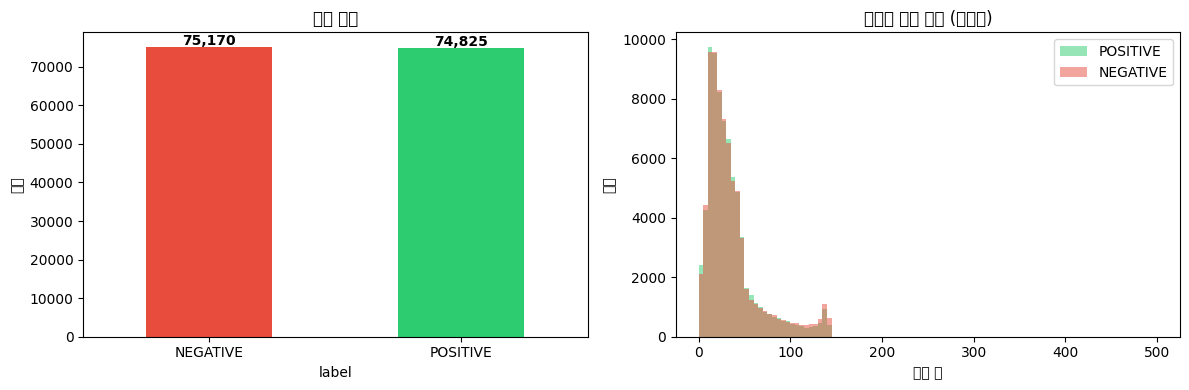


텍스트 길이 통계:
            count  mean   std  min   25%   50%   75%    max
label                                                      
NEGATIVE  75170.0  35.8  30.3  1.0  16.0  27.0  43.0  146.0
POSITIVE  74825.0  34.6  28.7  1.0  16.0  27.0  42.0  146.0


In [4]:
# 라벨 분포
label_counts = train_df["label"].value_counts()
print("라벨 분포:")
print(label_counts)
print(f"\nPOSITIVE 비율: {(train_df['label'] == 'POSITIVE').mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 막대 그래프
label_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('라벨 분포')
axes[0].set_ylabel('개수')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(label_counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# 텍스트 길이 분포 (라벨별)
train_df['text_len'] = train_df['text'].str.len()
for label, color in [('POSITIVE', '#2ecc71'), ('NEGATIVE', '#e74c3c')]:
    subset = train_df[train_df['label'] == label]['text_len']
    axes[1].hist(subset, bins=100, alpha=0.5, label=label, color=color, range=(0, 500))
axes[1].set_title('텍스트 길이 분포 (라벨별)')
axes[1].set_xlabel('문자 수')
axes[1].set_ylabel('빈도')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n텍스트 길이 통계:")
print(train_df.groupby('label')['text_len'].describe().round(1))

In [5]:
# 중복 텍스트 확인
dup_count = train_df.duplicated(subset=["text"]).sum()
print(f"중복 텍스트 수: {dup_count:,}개 / 전체 {len(train_df):,}개")

# 같은 텍스트에 다른 라벨이 달린 경우 (라벨 충돌)
conflict = train_df.groupby('text')['label'].nunique()
conflict_count = (conflict > 1).sum()
print(f"라벨 충돌 텍스트 수: {conflict_count:,}개")

중복 텍스트 수: 3,813개 / 전체 149,995개
라벨 충돌 텍스트 수: 157개


[길이-감성 상관] Pearson corr = -0.0204

[욕설 포함 여부 비율]
                count  pos_ratio  neg_ratio
has_profanity                              
False          145541   0.510550   0.489450
True             4454   0.116524   0.883476

[강조 기호별 비율 차이 (POS - NEG)]
  signal  count  pos_ratio  neg_ratio  ratio_diff
0     !!   6618   0.744334   0.255666    0.488667
1     ??   2051   0.296928   0.703072   -0.406143
2     ㅋㅋ   9612   0.571161   0.428839    0.142322
3     ㅠㅠ   3610   0.708864   0.291136    0.417729
4     ㅎㅎ   2892   0.817773   0.182227    0.635546


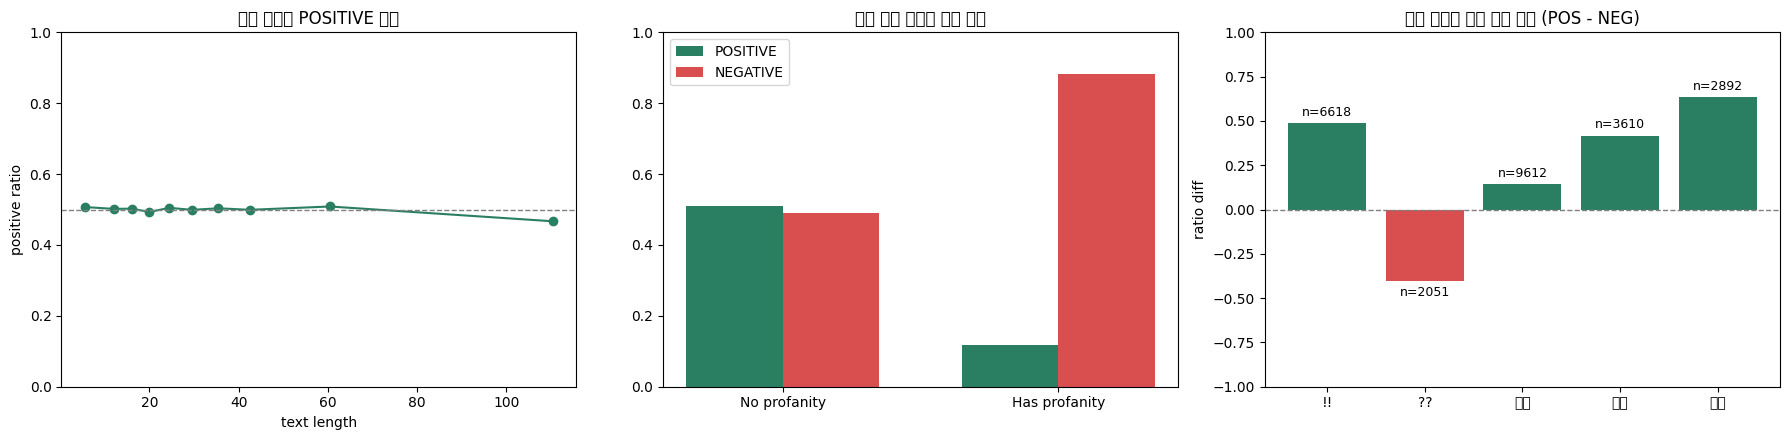

In [6]:
# 욕설/강조기호와 감성 상관 분석
eda = train_df[["text", "label"]].copy()
eda["text"] = eda["text"].fillna("").astype(str)
eda["label_bin"] = (eda["label"].str.upper() == "POSITIVE").astype(int)
eda["text_len"] = eda["text"].str.len()

# 텍스트 길이와 감성 상관
len_corr = eda["text_len"].corr(eda["label_bin"])
print(f"[길이-감성 상관] Pearson corr = {len_corr:.4f}")

len_bin = pd.qcut(eda["text_len"], q=10, duplicates="drop")
len_stats = eda.groupby(len_bin)["label_bin"].mean().reset_index(name="pos_ratio")
len_stats["bin_mid"] = len_stats["text_len"].apply(lambda x: (x.left + x.right) / 2)

# 욕설 포함 여부별 긍/부정 비율
profanity_re = r"ㅅㅂ|시발|씨발|존나|병신|개새끼|미친|쓰레기|좆|좃|ㅂㅅ|ㅄ"
eda["has_profanity"] = eda["text"].str.contains(profanity_re, regex=True, na=False)
profanity_stats = eda.groupby("has_profanity")["label_bin"].agg(["mean", "count"]).rename(columns={"mean": "pos_ratio"})
profanity_stats["neg_ratio"] = 1 - profanity_stats["pos_ratio"]
profanity_stats = profanity_stats.reindex([False, True]).fillna(0)

# 강조 기호별 비율 차이
signal_patterns = {"!!": r"!{2,}", "??": r"\?{2,}", "ㅋㅋ": r"ㅋ+", "ㅠㅠ": r"[ㅠㅜ]{2,}", "ㅎㅎ": r"ㅎ+"}
signal_rows = []
for sig, pattern in signal_patterns.items():
    m = eda["text"].str.contains(pattern, regex=True, na=False)
    pos_ratio = eda.loc[m, "label_bin"].mean() if m.any() else np.nan
    signal_rows.append({
        "signal": sig, "count": int(m.sum()), "pos_ratio": pos_ratio,
        "neg_ratio": 1 - pos_ratio if pd.notna(pos_ratio) else np.nan,
        "ratio_diff": (2 * pos_ratio - 1) if pd.notna(pos_ratio) else np.nan,
    })
signal_stats = pd.DataFrame(signal_rows)

print("\n[욕설 포함 여부 비율]")
print(profanity_stats[["count", "pos_ratio", "neg_ratio"]])
print("\n[강조 기호별 비율 차이 (POS - NEG)]")
print(signal_stats[["signal", "count", "pos_ratio", "neg_ratio", "ratio_diff"]])

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(len_stats["bin_mid"], len_stats["pos_ratio"], marker="o", color="#2a7f62")
axes[0].axhline(0.5, ls="--", c="gray", lw=1)
axes[0].set_title("길이 구간별 POSITIVE 비율")
axes[0].set_xlabel("text length")
axes[0].set_ylabel("positive ratio")
axes[0].set_ylim(0, 1)

x = np.arange(2)
w = 0.35
axes[1].bar(x - w / 2, profanity_stats["pos_ratio"], width=w, color="#2a7f62", label="POSITIVE")
axes[1].bar(x + w / 2, profanity_stats["neg_ratio"], width=w, color="#d94e4e", label="NEGATIVE")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["No profanity", "Has profanity"])
axes[1].set_ylim(0, 1)
axes[1].set_title("욕설 포함 여부별 감성 비율")
axes[1].legend()

bar_colors = ["#2a7f62" if v >= 0 else "#d94e4e" for v in signal_stats["ratio_diff"].fillna(0)]
axes[2].bar(signal_stats["signal"], signal_stats["ratio_diff"], color=bar_colors)
axes[2].axhline(0, ls="--", c="gray", lw=1)
axes[2].set_ylim(-1, 1)
axes[2].set_title("강조 기호별 감성 비율 차이 (POS - NEG)")
axes[2].set_ylabel("ratio diff")
for i, row in signal_stats.reset_index(drop=True).iterrows():
    if pd.notna(row["ratio_diff"]):
        axes[2].text(i, row["ratio_diff"] + (0.04 if row["ratio_diff"] >= 0 else -0.08),
                     f"n={int(row['count'])}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# EDA 전용 컬럼 정리
train_df = train_df.drop(columns=["text_len"], errors="ignore")

## 3. 텍스트 전처리 — 토큰화, 벡터화

### 3.1 데이터 클리닝

- **중복 텍스트 제거**: 동일 텍스트가 여러 번 들어가면 TF-IDF의 IDF 값이 왜곡됨
- **HTML 태그/CSV 아티팩트 정리**: `<br>`, 연속 따옴표 등 제거
- **무의미 노이즈 제거**: `ㄱㄱㄱㄱ`, `??!?!?` 같은 자모/기호만으로 된 텍스트는 감성 판단에 무의미
- **라벨 충돌 제거**: 동일 텍스트에 POSITIVE/NEGATIVE 둘 다 달린 경우 모델에 혼란을 줌

In [7]:
# 중복 텍스트 제거
before_dedup = len(train_df)
dropped_dup_rows = train_df.duplicated(subset=["text"]).sum()
train_df = train_df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
print(f"중복 text 제거: {int(dropped_dup_rows)}개 행 삭제 ({before_dedup} -> {len(train_df)})")

# HTML/CSV 아티팩트 정리 (train, test 모두)
for df in (train_df, test_df):
    df["text"] = df["text"].str.replace(r'<([^>]+)>', r'\1', regex=True)
    df["text"] = df["text"].str.replace(r'"{2,}', '', regex=True)

# train 전용 정제: 무의미 텍스트 + 라벨 충돌 제거
train_df = train_df[~train_df['text'].str.match(r'^[ㄱ-ㅎㅏ-ㅣ.,!?~\s\-…\d]+$')]

conflict = train_df.groupby('text')['label'].nunique()
conflict = conflict[conflict > 1].index
train_df = train_df[~train_df['text'].isin(conflict)].reset_index(drop=True)

print(f"클리닝 후 Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

# 라벨 변환
y_str = train_df["label"].astype(str).str.strip().str.upper().values
y     = (y_str == "POSITIVE").astype(int)

# 5-fold 분할기 (전체 파이프라인에서 공유)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

중복 text 제거: 3813개 행 삭제 (149995 -> 146182)
클리닝 후 Train: (145930, 3)
Test: (49997, 2)


### 3.2 Regex 기반 텍스트 정규화

- **욕설 변형**: `씨발/시발/씨빨/ㅅㅂ` → 모두 같은 의미이므로 하나로 통일
- **신조어/슬랭**: `꿀잼/개잼/존잼` → `재미있다`, `쩐다/쩔어` → `매우 좋다`
- **오타/구어체**: `재밋/잼없/별루` → 표준형으로 교정
- **역접 구조 강조**: `지루하지만 재밌다` → `지만 재밌 재밌` (역접 뒤 감성어를 반복하여 TF-IDF 가중치 강화)

In [8]:
profanity_map = [
    # --- 시발 계열 ---
    (r"씨발|시발|씨빨|시빨|ㅅ발|씨팔|시팔|씨불|시불|쉬발|쉬빨|씹할|씹발|씨봘|시봘|씨벌|시벌|씨바|시바알|씨방|시방새|씨1발|시1발|씨X", "시발"),
    (r"ㅅㅂ", "시발"),
    (r"씨부[랄럴]|시부[랄럴]|씨부리|시부리", "시발"),
    (r"(?<![가-힣A-Za-z0-9])ㅗ(?:\s*ㅗ)*(?![가-힣A-Za-z0-9])", "욕설"),
    # --- 존나 계열 ---
    (r"존나|졸라|존내|졸래|조낸|존낮|존맛|존마|좆나|존1나", "존나"),
    (r"ㅈㄴ", "존나"),
    # --- 좆 계열 ---
    (r"좆같|좃같|지같|ㅈ같|좇같|졷같|X같|x같", "좆같"),
    (r"좆|좃|좇|졷|조까", "좆"),
    (r"ㅈㄲ", "좆"),
    # --- 병신 계열 ---
    (r"병신|병싄|빙신|벼신|뼝신|병쉰|븅신|븅쉰|ㅂ1ㅅ", "병신"),
    (r"ㅂㅅ|ㅄ", "병신"),
    # --- 개새끼 / 새끼 계열 ---
    (r"개새끼|개색끼|개쉑|개세끼|개쌔끼|개시키|개쎄끼|개섹기", "개새끼"),
    (r"개놈|개년|개련|개놉", "개새끼"),
    (r"새끼|색끼|쌔끼|섹기|색히|샊|샤끼|쉑|썌|쎄끼|세꺄|새키|새1끼", "새끼"),
    (r"ㅅㄲ", "새끼"),
    # --- 지랄 / 미친 / 쓰레기 ---
    (r"지랄|지럴|지롤|짓거리|지럴맞", "지랄"),
    (r"ㅈㄹ", "지랄"),
    (r"미친[놈년것거]|미챤|미칀|미칫|미췬|미쳣", "미친놈"),
    (r"ㅁㅊ", "미친놈"),
    (r"쓰레기|쓰래기|쓸래기|쓸레기|쓰렉|쓰래키", "쓰레기"),
    (r"ㅆㄹㄱ", "쓰레기"),
    # --- 꺼져 / 닥쳐 / 니미 ---
    (r"꺼져|꺼저|꺼지[라세]", "꺼져"),
    (r"ㄲㅈ", "꺼져"),
    (r"닥쳐|닥쵸|닦쳐|닥치라|닥쳐라", "닥쳐"),
    (r"느금마|니미[럴랄]?|느금|니엄|니어미|느금빠|느그엄마|니어매", "니미"),
    # --- 찐따 / 꼴값 / 염병 ---
    (r"찐따|찐다|찐빠|찌질|찌질이", "찐따"),
    (r"ㅉㄸ", "찐따"),
    (r"꼴값|꼴통|꼴불|꼴깝|꼴좋|꼴갑", "꼴값"),
    (r"염병|옘병|엠병|얨병", "염병"),
    # --- 걸레 / 또라이 / 강한 감성 단독 표현 ---
    (r"걸레[같년놈]", "걸레"),
    (r"또라이|돌아이|또래이|또라인", "또라이"),
    (r"노답|노답이|노답임", "노답"),
    (r"거지같|거지같은|거지같네", "거지같"),
    (r"지옥같|지옥이다", "최악"),
    (r"역겨워|역겹다|역겨운|역겨움", "역겨움"),
    # --- 알파벳 욕설 ---
    (r"(?<![A-Za-z])OO+(?![A-Za-z])", " 욕설 "),
    (r"fuck|fcuk|fck|fuk", "욕설"),
    (r"shit|sht", "욕설"),
]


slang_map = [
    # '쩐다/쩔어' → 명확한 긍정
    (r"(?<![어])쩐[다네]|(?<![어])쩔어|(?<![어])쩔었|(?<![어])쩌네", "매우 좋다"),
    (r"(?<![가-힣])쩔(?![수]|[가-힣])", "매우 좋다"),
    (r"개쩐", "매우 좋다"),
    # 긍정 감탄사
    (r"(?<![가-힣])(?:캬+|크+아?|와우|우왕)(?![가-힣])", " 감탄 "),
    (r"대박(?=[이아][다네]|났|이네|이야|!)", "최고"),
    # '잘 만들' 계열
    (r"잘\s*만들(?:었|어|어진|어졌|긴|다|어낸)", "훌륭하게 만든"),
    (r"잘\s*만든", "훌륭한"),
    # '기대 이상'
    (r"기대\s*이상|기대\s*했던\s*것?보다|예상\s*보다", "기대이상"),
    # 명작급 긍정
    (r"진국|명품|명불허전", "명작"),
    # 긍정 맥락
    (r"덕분에", "감사하게"),

    # === FN 개선 (긍정 신호 강화) ===
    (r"실망\s*(?:안|하지|시키지)\s*않|실망\s*없|실망\s*없는", "만족스러운 기대이상"),
    (r"기대\s*저버리지\s*않|저버리지\s*않는", "기대이상 만족"),
    (r"재미만은\s*보장|재미만은", "재미있다 강조긍정"),
    (r"수준급|역작|인생영화|인생작", "명작 최고"),
    (r"기억할\s*만한|평생\s*기억", "명작"),
    (r"만족\s*했|만족스러운", "매우 좋다"),
    (r"잘\s*찍", "훌륭하게 찍은"),

    # === FP 개선 (부정 신호 강화) ===
    (r"만\s*기억\s*(?:남|난)|만\s*기억에\s*남", "만기억 나머지별로"),
    (r"(?:하나만|딱\s*하나만)\s*(?:좋|괜찮)", "하나만좋음 나머지별로"),
    (r"보지\s*마세요|보지\s*마[셈라]|비추\s*합니다|비추입니다", "비추 최악"),
    (r"돈\s*아까우니\s*보지", "낭비 비추 최악"),
    (r"재미가?\s*빠졌|재미가?\s*없어졌", "재미없다 별로"),
    (r"깊이가?\s*없다|깊이가?\s*부족", "얕다 별로"),
    (r"평작으로\s*종결|평작\s*수준", "평범한 별로"),
    (r"수작이?\s*될\s*수\s*있었는데", "아쉬운 별로"),
    (r"어릴\s*땐?\s*좋았(?:는데|지만)|예전엔?\s*좋았(?:는데|지만)", "지금은별로"),
    (r"그때는\s*좋|그땐\s*좋", "지금은별로"),
    (r"억지\s*감동|억지웃음|억지스러움|억지스럽", "억지 별로"),

    # === 추가 신조어/문맥 규칙 ===
    (r"핵?발암|개발암", "짜증나다 답답하다"),
    (r"개?극혐", "혐오 최악"),
    (r"사이다\s*(?:영화|전개)", "속시원하다"),
    (r"고구마\s*(?:전개|답답)", "답답하다"),
]


contrast_boost_safe = [
    (r"(?:지만|하지만|는데|인데|근데)\s*(재밌|재미있|좋|괜찮|훌륭|명작|걸작|볼만|강추|최고)",
     r"지만 \1 \1 "),
    (r"(?:지만|하지만|는데|인데|근데)\s*(별로|아쉽|실망|최악|지루|재미없|노잼)",
     r"지만 \1 \1 "),
]


typo_map = [
    # (A) '잼/재미'
    (r"재밋", "재밌"),
    (r"잼잇", "재미있"),
    (r"재미잇", "재미있"),
    (r"잼없|잼엄|잼업", "재미없"),
    (r"재미업(?![다는음어지게고서])", "재미없"),
    (r"재미읎", "재미없"),
    (r"재미엄", "재미없"),
    (r"제미없", "재미없"),
    (r"제미있|제미잇", "재미있"),
    (r"재미어ㅃㅅ", "재미없"),
    (r"(?<![가-힣])제미(?![가-힣])", "재미"),
    (r"(?<![가-힣])잼([나있남써])", r"재미있"),
    (r"재밋([는다어요])", r"재밌\1"),
    (r"(?<![가-힣])잼(?![가-힣])", "재밌"),
    # (B) 받침 오타
    (r"업([다는음어지게고서])", r"없\1"),
    (r"업떠", "없다"),
    (r"됫", "됐"),
    (r"(?<![가-힣])됏", "됐"),
    (r"(?<![가-힣])됬", "됐"),
    (r"(?<![가-힣])봣", "봤"),
    (r"(?<![가-힣])밧(?![가-힣])", "봤"),
    (r"밨", "봤"),
    (r"(?<![가-힣])잇([어다네는음])", r"있\1"),
    (r"꼴리티", "퀄리티"),
    # (C) 긍정 감성 오타
    (r"조타", "좋다"),
    (r"조앗|조았", "좋았"),
    (r"조와", "좋아"),
    (r"좋앗", "좋았"),
    (r"좋앙", "좋아"),
    (r"좋타", "좋다"),
    (r"조으", "좋으"),
    (r"멋잇", "멋있"),
    (r"괜찬", "괜찮"),
    (r"괜차[늠는나]", "괜찮은"),
    (r"괸찬은", "괜찮은"),
    (r"알흠답다", "아름답다"),
    (r"훌룡", "훌륭"),
    # (D) 부정 감성 오타
    (r"별루|벌로|별노", "별로"),
    (r"(?<![가-힣])그닥(?![가-힣])", "그다지"),
    (r"실타", "싫다"),
    (r"시러", "싫어"),
    (r"쓰러기", "쓰레기"),
    (r"어의없", "어이없"),
    # (E) 강조 부사
    (r"(?<![가-힣])마니(?![가-힣])", "많이"),
    (r"넘넘넘+|넘넘", "너무"),
    (r"(?<![가-힣])넘나(?![가-힣])", "너무"),
    # (F) 일반 오타/구어
    (r"진자(?![석전체기])", "진짜"),
    (r"(?<![가-힣])머([냐야가])(?![가-힣])", r"뭐\1"),
    (r"(?<![가-힣])디게(?![가-힣])", "되게"),
    (r"솔찍히", "솔직히"),
    (r"(?<![가-힣])걍(?![가-힣])", "그냥"),
    (r"우와아+|와아+|(?<![가-힣])와우(?![가-힣])", "우와"),
    (r"글케", "그렇게"),
    (r"이건뭐", "이건 뭐"),
    (r"저건뭐", "저건 뭐"),
    (r"같[애에](?![서])", "같아"),
    (r"어[캐케](?![서])", "어떻게"),
    (r"어뜨케", "어떻게"),
    (r"안됌", "안됨"),
    (r"안됫", "안됐"),
    (r"증[말맬]", "정말"),
    (r"어떡해", "어떻게 해"),
    (r"어용$", "어요"),
    (r"아용$", "아요"),
    (r"그치만", "그렇지만"),
    (r"싶[따당]", "싶다"),
    (r"마은", "마음"),
    (r"(?<![가-힣])굳(?![가-힣])", "좋"),
    (r"굳굳", "좋"),
    (r"굿굿", "좋"),
    (r"(?<![가-힣])모([냐삼])(?![가-힣])", r"뭐\1"),
    (r"머시여|머시야", "뭐야"),
    (r"뭐임|머임", "뭐야"),
    (r"(?<![가-힣])나두(?![가-힣])", "나도"),
    (r"(?<![가-힣])실어(?![가-힣])", "싫어"),
    (r"가치", "같이"),
    (r"짱나", "짜증나"),
    (r"재밌당", "재밌다"),
    (r"좋당", "좋다"),
    (r"강열", "강렬"),
    # 신조어
    (r"킹받다", "열받다"),
    (r"꿀잼|개꿀잼|존잼|개잼|졸잼|핵잼", "재미있다"),
    (r"노잼|개노잼|핵노잼|씹노잼|극노잼", "재미없다"),
    (r"갓벽", "완벽"),
    (r"갓작|띵장", "완벽한 작품"),
    (r"망작|졸작", "망한 작품"),
    (r"쏘쏘", "보통"),
    (r"ㄹㅇ", "진짜"),
    (r"노답|개노답|핵노답|십노답", "답이 없다"),
    (r"쩐다|짱", "대박"),
    (r"개꿀|굿|핵꿀", "좋다"),
    (r"강추", "강력추천"),
    (r"비추", "추천 안하다"),
    (r"레알", "진짜"),
    (r"존예|지존예", "예쁘다"),
    (r"존멋", "멋있다"),
    (r"존좋", "좋다"),
    
    (r"재목", "제목"),
]

HEART_CHARS = re.compile(r"[\u2665\u2661\u2765\u2763\U0001F495\U0001F49E\U0001F493\U0001F497\U0001F496\U0001F498\U0001F49D\U0001F49F\U0001F9E1\U0001F49B\U0001F49A\U0001F499\U0001F49C\U0001F5A4\U0001F90D\U0001F90E]")


def preprocess_text_series(s: pd.Series) -> pd.Series:
    s = s.copy()

    # 중간에 낀 !?를 맨 뒤로 이동 (감탄/의문 신호 보존)
    def move_punct_to_end(text):
        puncts = re.findall(r'[!?]+', text)
        cleaned = re.sub(r'\s*[!?]+\s*', ' ', text).strip()
        suffix = ''.join(puncts)
        suffix = re.sub(r'!+', '!!', suffix)
        suffix = re.sub(r'\?+', '??', suffix)
        return (cleaned + ' ' + suffix).strip() if suffix else cleaned
    s = s.apply(move_punct_to_end)

    # 마스킹된 'OOO'을 '욕설'로 통일
    s = s.str.replace(r"(?<![A-Za-z])O{2,}(?![A-Za-z])", " 욕설 ", regex=True)
    s = s.str.lower()

    for pattern, replacement in profanity_map:
        s = s.str.replace(pattern, replacement, regex=True)

    for pattern, replacement in slang_map:
        s = s.str.replace(pattern, replacement, regex=True)

    # 반복 기호/자모 정규화
    s = s.str.replace(r"!{2,}", "!!", regex=True)
    s = s.str.replace(r"\?{2,}", "??", regex=True)
    s = s.str.replace(r"~{2,}", "~~", regex=True)
    s = s.str.replace(r"ㅋ[\sㅋ]*ㅋ+", "ㅋㅋ", regex=True)
    s = s.str.replace(r"ㅎ[\sㅎ]*ㅎ+", "ㅎㅎ", regex=True)
    s = s.str.replace(r"ㅠ[\sㅠ]*ㅠ+", "ㅠㅠ", regex=True)
    s = s.str.replace(r"ㅜ[\sㅜ]*ㅜ+", "ㅜㅜ", regex=True)
    s = s.str.replace(r"ㅡ[\sㅡ]*ㅡ+", "ㅡㅡ", regex=True)
    s = s.str.replace(r"ㄱ[\sㄱ]*ㄱ+", "ㄱㄱ", regex=True)
    s = s.str.replace(r"\.{3,}", "..", regex=True)
    s = s.str.replace(HEART_CHARS, "\u2764", regex=True)
    s = s.str.replace(r"\^[\^_o]+\^?", " 웃음 ", regex=True)
    s = s.str.replace(r"[ㅜㅠ]\.[ㅜㅠ]", "ㅠㅠ", regex=True)
    s = s.str.replace(r"ㅡㅡ;+", " ㅡㅡ ", regex=True)
    s = s.str.replace(r"ㅡ\.ㅡ", "ㅡㅡ", regex=True)
    s = s.str.replace(r":\)|:D|;\)", " 웃음 ", regex=True)
    s = s.str.replace(r":\(", " 슬픔 ", regex=True)

    for pattern, replacement in typo_map:
        s = s.str.replace(pattern, replacement, regex=True)

    # 역접 뒤 감성어 강조
    for pattern, replacement in contrast_boost_safe:
        s = s.str.replace(pattern, replacement, regex=True)

    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s


print(f"profanity_map: {len(profanity_map)}, slang_map: {len(slang_map)}, "
      f"typo_map: {len(typo_map)}, contrast_boost: {len(contrast_boost_safe)}")

profanity_map: 38, slang_map: 32, typo_map: 98, contrast_boost: 2


### 3.3 형태소 분석

**USEFUL_POS 필터**: 조사(JKS, JKO 등), 어미(EP, EF 등), 구두점은 감성 판단에 무의미하므로 제거. 명사, 동사, 형용사, 부사, 감탄사 등 감성 신호가 있거나 감성 신호에 도움되는 있는 품사만 유지.

**부정 합성 토큰**: `안 좋다`를 `안`, `좋다` 두 토큰으로 분리하면 TF-IDF에서 `좋다`가 긍정으로 잡힘. `안_좋다`로 합쳐서 부정 의미를 보존.

In [9]:
kiwi = Kiwi(typos="basic_with_continual")

USER_DICT = [
    ("묘하다", "VA"),
    ("cgv", "NNP"), ("메가박스", "NNP"), ("롯데시네마", "NNP"), ("imax", "NNP"),
    ("노답", "NNG"),
    ("실화냐", "IC"), ("강추", "IC"), ("극찬", "NNG"), ("대박", "IC"), ("알바", "NNG"),
    ("허접", "VA"), ("막장", "NNG"), ("꽝", "NNG"), ("개판", "NNG"), ("개소리", "NNG"),
    ("홍보", "NNG"),
    ("발연기", "NNG"), ("심쿵", "NNG"), ("몰입감", "NNG"), ("개연성", "NNG"),
    ("킬링타임", "NNG"), ("억지감동", "NNG"), ("억지웃음", "NNG"),
    ("눈호강", "NNG"), ("귀호강", "NNG"),
    ("소름돋다", "VA"), ("현타", "NNG"), ("시간낭비", "NNG"), ("돈낭비", "NNG"),
    ("4dx", "NNP"), ("ost", "NNG"), ("쿠키영상", "NNG"),
    ("스포일러", "NNG"), ("복선", "NNG"),
    ("0점", "NNG"), ("1점", "NNG"), ("10점", "NNG"), ("100점", "NNG"),
    ("명작", "NNG"), ("수작", "NNG"), ("걸작", "NNG"), ("완벽", "NNG"),
    ("명품", "NNG"), ("레전드", "NNG"), ("인생영화", "NNG"), ("역작", "NNG"),
    ("재앙", "NNG"), ("망함", "NNG"),
    ("낚시", "NNG"), ("쓰렉", "NNG"), ("평점테러", "NNG"),
    ("쩔어", "VA"), ("쩔었", "VA"), ("짱이", "VA"), ("낚였", "VV"), ("킹왕짱", "IC"),
    ("연기력", "NNG"), ("연출력", "NNG"), ("스토리", "NNG"), ("힐링", "NNG"),
    ("떡밥", "NNG"), ("cg", "NNP"), ("부적절", "NNG"),
    ("완전", "MAG"), ("ㄷㄷ", "IC"),
]

for word, pos in USER_DICT:
    kiwi.add_user_word(word, pos)

print(f"USER_DICT 등록: {len(USER_DICT)}개")

USER_DICT 등록: 66개


In [10]:
USEFUL_POS = {
    'VA', 'VA-R', 'VA-I', 'VV', 'VV-R', 'VV-I', 'VX',
    'VCN', 'VCP', 'NNG', 'NNP', 'NNB', 'NP', 'NR',
    'MAG', 'MAJ', 'MM', 'IC', 'XR', 'SL', 'SW', 'W_EMOJI', 'SF',
}

# 부정 합성 토큰 생성을 위한 집합
NEG_PREFIX_ADV    = {"안", "못"}
NEG_SUFFIX_VX     = {"않", "않다"}
NEG_SUFFIX_ABSENT = {"없", "없다"}
NEG_SUFFIX_VCN    = {"아니", "아니다"}


def kiwi_tokenize(s: pd.Series) -> pd.Series:
    """Kiwi 토큰화 + USEFUL_POS 필터 + 부정 합성 토큰 생성."""
    def _one(text):
        if not isinstance(text, str) or not text.strip():
            return []
        tokens = kiwi.tokenize(text)
        filtered = [(t.form, t.tag) for t in tokens if t.tag in USEFUL_POS]

        result = []
        i = 0
        while i < len(filtered):
            form, tag = filtered[i]

            # "안/못 + V" -> 안_V
            if form in NEG_PREFIX_ADV and tag == "MAG":
                if i + 1 < len(filtered) and filtered[i+1][1] in ("VV", "VA"):
                    result.append(f"{form}_{filtered[i+1][0]}")
                    i += 2
                    continue

            # "V + (지) + 않" -> V_않다
            if tag in ("VV", "VA"):
                j = i + 1
                if j < len(filtered) and filtered[j][0] == "지":
                    j += 1
                if j < len(filtered) and filtered[j][0] in NEG_SUFFIX_VX and filtered[j][1] == "VX":
                    result.append(f"{form}_않다")
                    i = j + 1
                    continue

            # "N + 없" -> N_없다
            if tag in ("NNG", "NNB"):
                if i + 1 < len(filtered):
                    nf, nt = filtered[i+1]
                    if nf in NEG_SUFFIX_ABSENT and nt == "VA":
                        result.append(f"{form}_없다")
                        i += 2
                        continue

            # "N + 아니" -> N_아니다
            if tag == "NNG":
                if i + 1 < len(filtered):
                    nf, nt = filtered[i+1]
                    if nf in NEG_SUFFIX_VCN and nt == "VCN":
                        result.append(f"{form}_아니다")
                        i += 2
                        continue

            result.append(form)
            i += 1
        return result

    return s.apply(_one)

### 3.4 전처리 적용 + TF-IDF 입력 준비

In [11]:
# regex 정규화 적용
train_df["text_preprocessed"] = preprocess_text_series(train_df["text"])
test_df["text_preprocessed"]  = preprocess_text_series(test_df["text"])

# Kiwi 토큰화 (Word TF-IDF 입력용)
train_df["text_tokenized"] = kiwi_tokenize(train_df["text_preprocessed"])
test_df["text_tokenized"]  = kiwi_tokenize(test_df["text_preprocessed"])

# TF-IDF 입력 2종:
#   - Word: Kiwi 토큰 (공백 join) -> 형태소 단위 n-gram
#   - Char: preprocessed raw text -> 문자 단위 n-gram (오타/변형에 강건)
def _join_tokens(tokens):
    return " ".join(tokens) if isinstance(tokens, list) else ""

train_kiwi = train_df["text_tokenized"].apply(_join_tokens).values
test_kiwi  = test_df["text_tokenized"].apply(_join_tokens).values
train_raw  = train_df["text_preprocessed"].fillna("").astype(str).values
test_raw   = test_df["text_preprocessed"].fillna("").astype(str).values

print(f"전처리 완료: train {len(train_df)}, test {len(test_df)}")
print(f"예시 - tokens: {train_kiwi[0][:80]}")
print(f"예시 - raw:    {train_raw[0][:80]}")

전처리 완료: train 145930, test 49997
예시 - tokens: 아이 싱겁 .. ㅠㅠ
예시 - raw:    아이 싱거워라..ㅠㅠ


## 4. 모델 학습 — 알고리즘 선택 이유, 하이퍼파라미터 근거

### 왜 NBSVM인가?

1. **Naive Bayes의 로그 비율 `r`**: 각 단어가 긍정/부정 클래스에서 얼마나 자주 나오는지의 비율. 이 값을 TF-IDF 피처에 곱하면, 감성 판별력이 높은 단어에 자동으로 높은 가중치가 부여됨.
2. **SVM의 결정 경계**: : RL과 다르게 SVM은 마진 안쪽 샘플들만 신경쓰기 때문에, 이상치, 오라벨에 둔감한 장점.

### Word TF-IDF + Char TF-IDF 결합 이유
- **Word TF-IDF**: Kiwi 형태소 분석 결과를 입력으로, 의미 단위의 n-gram 포착
- **Char TF-IDF**: 원문을 문자 단위로 분석하여 오타, 변형 표현, 형태소 분석 실패에 강건
- 두 TF-IDF를 `hstack`으로 결합하여 상호 보완

### 하이퍼파라미터 근거

아래 하이퍼파라미터는 Optuna TPE 탐색기로 60 trials x 5-fold OOF MCC를 최대화하여 찾은 값 (best OOF MCC = **0.76084**):

| 항목 | 값 |
|---|---|
| `word_ngram_max` | [2, 3, 4] |
| `word_min_df` | [2, 3, 5] |
| `word_max_df` | 0.80~0.98 |
| `word_max_features` | 80k/120k/200k/None |
| `char_ngram_max` | [3, 4, 5, 6] |
| `char_min_df` | [2, 3, 5] |
| `char_max_df` | 0.80~0.99 |
| `char_max_features` | 200k/400k/600k/None |
| `alpha_nb` | 0.1~5.0 (log) |
| `char_alpha` | 0.3~3.0 |
| `svm_C` | 0.01~20.0 (log) |
| `svm_loss` | hinge/squared_hinge |
| `threshold` | 0.30~0.70 |

In [12]:
# Optuna 60 trials x 5-fold OOF MCC 최대화로 찾은 최적 하이퍼파라미터
# best OOF MCC = 0.760840585173935
BEST_CONFIG = {
    "word_tfidf": {
        "ngram_range":  (1, 4), #1~4gram
        "min_df":       3,#3번 미만 ngram 삭제
        "max_df":       0.817925445730048,   # 전체 문서의 대략 81%를 초과로 등장하는 ngram을 제거
        "max_features": 200000,
    },
    "char_tfidf": {
        "ngram_range":  (2, 5), # 2gram~5gram
        "min_df":       3, #3번 미만 ngram 삭제
        "max_df":       0.943111997099138, # 전체 문서의 대략 94%를 초과로 등장하는 ngram을 제거
        "max_features": 400000,
    },
    "nbsvm": {
        "alpha_nb":   0.124286380301896,  # 라플라스 스무딩강도(작음)
        "char_alpha": 1.36221220363353, # Char 피처 가중치 (1.36배)
        "C":          0.223068701210195, # 강한 정규화(L2)
        "loss":       "squared_hinge", # margin 안쪽 샘플에 대해 더 큰 gradient를 부여함. 
    },
    "threshold": 0.544480789566647,
}

print("[Best Config]")
for section in ["word_tfidf", "char_tfidf", "nbsvm"]:
    print(f"  [{section}]")
    for k, v in BEST_CONFIG[section].items():
        print(f"    {k}: {v}")
print(f"  [threshold] {BEST_CONFIG['threshold']:.6f}")

[Best Config]
  [word_tfidf]
    ngram_range: (1, 4)
    min_df: 3
    max_df: 0.817925445730048
    max_features: 200000
  [char_tfidf]
    ngram_range: (2, 5)
    min_df: 3
    max_df: 0.943111997099138
    max_features: 400000
  [nbsvm]
    alpha_nb: 0.124286380301896
    char_alpha: 1.36221220363353
    C: 0.223068701210195
    loss: squared_hinge
  [threshold] 0.544481


### NBFeaturer 정의

NB의 로그 비율 `r = log(p(word|y=1) / p(word|y=0))`을 TF-IDF 피처에 곱해 SVM에 넣는 변환기.

- `r > 0`: 해당 단어가 긍정 클래스에서 더 자주 등장
- `r < 0`: 해당 단어가 부정 클래스에서 더 자주 등장
- `alpha`: 라플라스 스무딩. 한 번도 안 나온 단어의 확률이 0이 되는 것을 방지

In [13]:
class NBFeaturer(BaseEstimator, TransformerMixin):
    """NB 로그 비율 r을 학습하여 X.multiply(r)을 반환."""

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    #긍정/부정문서들에서 각 단어가 나올 확률
    def _pr(self, X, y_arr, y_i):
        
        # 클래스 y_i에 속한 문서들의 단어별 합계 (+ 스무딩)
        p = X[y_arr == y_i].sum(axis=0) + self.alpha
        return p / ((y_arr == y_i).sum() + self.alpha)

    def fit(self, X, y):
        y_arr = np.asarray(y)
        # r > 0 → 긍정 클래스에서 더 자주,  r < 0 → 부정 클래스에서 더 자주
        self.r_ = np.log(np.asarray(self._pr(X, y_arr, 1) / self._pr(X, y_arr, 0))).ravel()
        return self

    def transform(self, X):
        return X.multiply(self.r_)

### NBSVM 빌더 + 5-fold OOF 함수

`CalibratedClassifierCV(cv=3)`을 쓰는 이유: `LinearSVC`는 확률을 출력하지 못함(decision_function만 제공). 임계값 최적화에는 잘 보정된 0~1 확률이 필요하므로 calibration사용

In [14]:
#word-ngram
def build_word_vectorizer(params):
    return TfidfVectorizer(
        analyzer="word",
        ngram_range=params["ngram_range"],
        min_df=params["min_df"],
        max_df=params["max_df"],
        sublinear_tf=True, # 빈도를 로그 스케일로 압축 -> 단어가 10번 나왔다고 10배 중요한것은 아님
        max_features=params["max_features"],
        token_pattern=r"(?u)\S+", # Kiwi로 이미 토큰화됨 → 공백 기준으로만 자름
    )

#char-hgram
def build_char_vectorizer(params):
    return TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=params["ngram_range"],
        min_df=params["min_df"],
        max_df=params["max_df"],
        sublinear_tf=True,
        max_features=params["max_features"],
    )

#SVC모델
def build_nbsvm_clf(params):
    base = LinearSVC(
        C=params["C"],
        loss=params["loss"],
        max_iter=2000,
        random_state=RANDOM_STATE,
    )
    # SVC는 확률을 바로 안 주므로 CalibratedClassifierCV(cv=3)로 확률 보정
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)#분할고정
    return CalibratedClassifierCV(base, cv=cv)

#한 fold를 학습
def nbsvm_fit_fold(kiwi_train, raw_train, y_train, cfg):#형태소 텍스트, 원본, 정답레이블, 하이퍼파라미터 설정 딕셔너리
    """한 fold의 train 데이터로 vectorizer/NB/SVM 모두 fit."""
    
    #벡터라이저 Word, char
    vec_w = build_word_vectorizer(cfg["word_tfidf"]).fit(kiwi_train)
    vec_c = build_char_vectorizer(cfg["char_tfidf"]).fit(raw_train)

    #각 학습 텍스트를 벡터라이저로 변환 -> 행렬
    Xw = vec_w.transform(kiwi_train)
    Xc = vec_c.transform(raw_train)

    #각 단어/문자의 로그 비율학습
    nb_w = NBFeaturer(alpha=cfg["nbsvm"]["alpha_nb"]).fit(Xw, y_train)
    nb_c = NBFeaturer(alpha=cfg["nbsvm"]["alpha_nb"]).fit(Xc, y_train)

    #word 피처, char 피처를 가로로 합침. char_alpha(가중치)
    #tocsr() : SVM 연산에 효율적인 행렬 포멧으로 변환
    X_stack = hstack([
        nb_w.transform(Xw),
        nb_c.transform(Xc) * cfg["nbsvm"]["char_alpha"],
    ]).tocsr()

    #분류기 학습(NB로 피처변환 -> SVM으로 최종분류)
    clf = build_nbsvm_clf(cfg["nbsvm"]).fit(X_stack, y_train)
    return {"vec_w": vec_w, "vec_c": vec_c, "nb_w": nb_w, "nb_c": nb_c, "clf": clf}

#예측
def nbsvm_predict_proba(pipe, kiwi_x, raw_x, char_alpha):#pip : nbsvm_fit_fold가 반환한 학습 파이프라인
    
    # 새로운 텍스트를 벤터라이저 변환
    Xw = pipe["vec_w"].transform(kiwi_x)
    Xc = pipe["vec_c"].transform(raw_x)
    X_stack = hstack([
        pipe["nb_w"].transform(Xw),
        pipe["nb_c"].transform(Xc) * char_alpha,
    ]).tocsr()
    return pipe["clf"].predict_proba(X_stack)[:, 1]#예측한 확률값중 양상 클래스(1번열)만 반환

#교차검증
def run_oof(cfg, need_test=False, verbose=False):
    """5-fold OOF proba 생성. need_test=True면 test proba도 fold 평균으로 누적."""
    nbsvm_oof = np.zeros(len(y), dtype=float)
    nbsvm_test = np.zeros(len(test_df), dtype=float) if need_test else None

    #클래스 비율 유지하면서 train/valid split
    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_kiwi, y), 1):
        
        #이번 fold의 train 데이터 만으로 학습
        pipe = nbsvm_fit_fold(train_kiwi[tr_idx], train_raw[tr_idx], y[tr_idx], cfg)
        
        #학습에 쓰지이 않는 valid 데이터로 예측
        nbsvm_oof[va_idx] = nbsvm_predict_proba(
            pipe, train_kiwi[va_idx], train_raw[va_idx], cfg["nbsvm"]["char_alpha"]
        )
        
        #각 fold의 테스트 예측을 평균내어 누적(fold수로 나눔)->fold마다 다른 모델로 예측 후 평균
        if need_test:
            nbsvm_test += nbsvm_predict_proba(
                pipe, test_kiwi, test_raw, cfg["nbsvm"]["char_alpha"]
            ) / N_SPLITS
            
        #MCC값 계산
        if verbose:
            fold_mcc = matthews_corrcoef(y[va_idx], (nbsvm_oof[va_idx] >= 0.5).astype(int))
            print(f"  Fold {fold}: MCC@0.5 = {fold_mcc:.5f}")

    return nbsvm_oof, nbsvm_test


print("NBSVM 빌더/OOF 헬퍼 정의 완료")

NBSVM 빌더/OOF 헬퍼 정의 완료


## 5. 검증 및 평가 — train/validation 분할, 성능 측정, 혼동 행렬

5-fold Stratified K-Fold로 Out-of-Fold(OOF) 예측을 생성하여 모델 성능을 평가.
- 각 fold에서 학습 데이터로만 vectorizer/NB/SVM을 fit -> 검증 데이터로 예측 (데이터 누수 없음)
- 평가 지표: **MCC (Matthews Correlation Coefficient)** — 불균형 데이터에서도 안정적인 이진 분류 지표

In [15]:
print("=== 5-fold OOF 검증 + test proba 생성 ===")
oof_proba, test_proba = run_oof(BEST_CONFIG, need_test=True, verbose=True)

oof_pred = (oof_proba >= BEST_CONFIG["threshold"]).astype(int)
final_oof_mcc = matthews_corrcoef(y, oof_pred)

print(f"\nOOF MCC (threshold={BEST_CONFIG['threshold']:.4f}): {final_oof_mcc:.5f}")

=== 5-fold OOF 검증 + test proba 생성 ===
  Fold 1: MCC@0.5 = 0.75968
  Fold 2: MCC@0.5 = 0.76578
  Fold 3: MCC@0.5 = 0.76167
  Fold 4: MCC@0.5 = 0.75796
  Fold 5: MCC@0.5 = 0.75989

OOF MCC (threshold=0.5445): 0.76124


OOF Confusion Matrix ([[TN, FP], [FN, TP]]):
[[65660  7518]
 [ 9932 62820]]

OOF Classification Report:
              precision    recall  f1-score   support

    NEGATIVE     0.8686    0.8973    0.8827     73178
    POSITIVE     0.8931    0.8635    0.8780     72752

    accuracy                         0.8804    145930
   macro avg     0.8809    0.8804    0.8804    145930
weighted avg     0.8808    0.8804    0.8804    145930



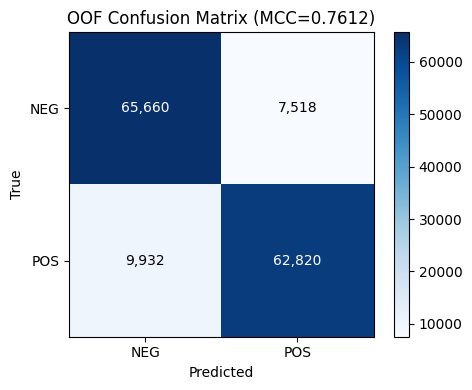

In [16]:
# 혼동 행렬
cm = confusion_matrix(y, oof_pred)
print("OOF Confusion Matrix ([[TN, FP], [FN, TP]]):")
print(cm)

print("\nOOF Classification Report:")
print(classification_report(y, oof_pred, target_names=["NEGATIVE", "POSITIVE"], digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["NEG", "POS"]); ax.set_yticklabels(["NEG", "POS"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"OOF Confusion Matrix (MCC={final_oof_mcc:.4f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 6. 테스트 예측 + CSV 생성 — 최종 예측 코드

In [17]:
test_pred = np.where(test_proba >= BEST_CONFIG["threshold"], "POSITIVE", "NEGATIVE")

submission = pd.DataFrame({
    "row_id":     test_df["row_id"],
    "pred_label": test_pred,
})

# 검증
assert set(submission["pred_label"].unique()) <= {"POSITIVE", "NEGATIVE"}, "라벨 집합 오류"
assert len(submission) == len(test_df), "행 수 불일치"

print(f"행 수: {len(submission)} (테스트 데이터와 동일)")
print(f"컬럼: {list(submission.columns)}")
print(f"\n예측 라벨 분포:")
print(submission["pred_label"].value_counts())
print(f"\nPOSITIVE 비율: {(submission['pred_label'] == 'POSITIVE').mean():.4f}")

print("\n제출 파일 샘플:")
submission.head(10)

행 수: 49997 (테스트 데이터와 동일)
컬럼: ['row_id', 'pred_label']

예측 라벨 분포:
pred_label
NEGATIVE    25757
POSITIVE    24240
Name: count, dtype: int64

POSITIVE 비율: 0.4848

제출 파일 샘플:


,row_id,pred_label
0,test-000001,POSITIVE
1,test-000002,POSITIVE
2,test-000003,NEGATIVE
3,test-000004,NEGATIVE
4,test-000005,NEGATIVE
5,test-000006,POSITIVE
6,test-000007,NEGATIVE
7,test-000008,NEGATIVE
8,test-000009,NEGATIVE
9,test-000010,POSITIVE


In [18]:
sub_path = os.path.join(OUT_DIR, "submission.csv")
submission.to_csv(sub_path, index=False, encoding="utf-8")
print(f"제출 파일 저장: {sub_path}")
print(f"형식: .csv, 인코딩: UTF-8")
print(f"필수 컬럼: {list(submission.columns)}")
print(f"허용 라벨: {sorted(submission['pred_label'].unique())}")

제출 파일 저장: ./submission.csv
형식: .csv, 인코딩: UTF-8
필수 컬럼: ['row_id', 'pred_label']
허용 라벨: ['NEGATIVE', 'POSITIVE']


## 7. 결론 — 시도한 접근법, 성공/실패 요인 분석

### 접근법 요약

| 단계 | 방법 | 설명 |
|---|---|---|
| 전처리 | regex 정규화 + Kiwi 형태소 분석 | 욕설/신조어/오타 통일, 부정 합성 토큰, 역접 강조 |
| 벡터화 | Word TF-IDF + Char TF-IDF | 형태소 n-gram + 문자 n-gram 결합 |
| 모델 | NBSVM (NB 가중 -> LinearSVC + Calibration) | 단일 모델, 스태킹 없음 |
| 평가 | 5-fold Stratified OOF MCC | 데이터 누수 없는 정직한 평가 |
| 임계값 | Optuna로 탐색 (0.5445) | 기본 0.5 대비 MCC 개선 |

### 성공 요인

1. **도메인 특화 전처리**: 한국어 영화 리뷰의 욕설 변형, 신조어, 오타를 정규화하여 어휘 수를 줄이고 TF-IDF 통계의 신뢰도를 높임
2. **부정 합성 토큰**: `안_재밌다`, `재미_없다` 등으로 부정 의미를 보존하여 False Positive 감소
3. **역접 구조 강조**: `지루하지만 재밌다`에서 역접 뒤 감성어를 반복하여 실제 감성을 강조
4. **Word + Char TF-IDF 결합**: 형태소 분석 실패에 대한 안전망 역할
5. **SVM** : SVM은 경계 근처만 보기 때문에 극단값에도 학습이 흔들리지 않음.

### 한계

1. **긴 문맥 이해 부족**: `처음엔 좋았는데 갈수록 망했다` 역접을 포착하기 어려움
2. **풍자/아이러니**: `이 영화 정말 대단하다 (비꼼)` 같은 표현은 긍정으로 오분류 가능

### 시도한 접근법, 실패 요인 분석

1. **CHAR-ngram 미시도** :  정규화 전처리에서 못잡은 변형 표기가 Char-ngram으로 잡혔다. 
2. **단독 로지스틱 회귀** : 
    - TF-IDF : "이 단어가 전체 문서에서 얼마나 희소한가", r 값 : "이 단어가 긍정/부정 중 어느쪽에서 나오는가"
    - 예를 들어 "시간낭비"라는 단어가 전체에서 50번 등장(긍정에서 2번, 부정에서 48번)했을때, 로지스틱 회귀가 w("시간낭비")를 학습하는 데 쓸 수 있는 샘플이 50개이므로 50번의 gradient update로 결정되지만, NB는 전체 학습 데이터에서 한번에 집계해서 안정적으로 r값이 계산된다. -> 가중치가 추정안정화
3. **형태소 필터링 최소화** : 동사,형용사,명사만을 사용해서 노이즈를 최소화한경우, 안,못 부정어나 그런데, 재미는 있는데 등등 n-gram효과가 떨어짐





---

# 메모

## 1. Word, Char n-gram 예시 

### 입력 데이터 (5문장 토이)

| # | Kiwi 토큰 (Word용) | Raw (Char용) |
|---|---|---|
| 0 | `영화 진짜 재밌다 강추` | `영화 진짜 재밌다 강추` |
| 1 | `스토리 안_좋다 시간 낭비` | `스토리 안 좋다 시간 낭비` |
| 2 | `연기 좋다 연출 명작` | `연기 좋다 연출 명작` |
| 3 | `재미_없다 노답 비추` | `재미 없다 노답 비추` |
| 4 | `배우 좋다 지만 영화 별로` | `배우 좋다 지만 영화 별로` |

### Word TF-IDF: `ngram_range=(1, 4)` — Kiwi 토큰 단위

| n | 개수 | 예시 |
|---|---|---|
| 1-gram | 18 | `강추`, `명작`, `안_좋다`, `재미_없다` |
| 2-gram | 15 | `연기 좋다`, `시간 낭비`, `스토리 안_좋다` |
| 3-gram | 10 | `영화 진짜 재밌다`, `재미_없다 노답 비추` |
| 4-gram | 5 | `스토리 안_좋다 시간 낭비`, `영화 진짜 재밌다 강추` |

### Char TF-IDF: `ngram_range=(2, 5)` `analyzer="char_wb"`

`'좋다'` 한 단어가 어떻게 쪼개지나:

```
원문:  '좋다'
패딩:  ' 좋다 '   ← 양 끝 공백
2-gram: [' 좋', '좋다', '다 ']
3-gram: [' 좋다', '좋다 ']
4-gram: [' 좋다 ']
5-gram: []         ← 단어가 짧아서 없음
```


---

# .pkl 코드 샘플

In [21]:

import numpy as np
import pandas as pd
import cloudpickle

model_path = "./models/nbsvm_portable.pkl"
train_path = "./data/public_train.csv"

train_df = pd.read_csv(train_path, encoding="utf-8")

with open(model_path, "rb") as f:
    portable_model = cloudpickle.load(f)

sample_df = train_df[["text", "label"]].sample(n=10, random_state=42).reset_index(drop=True)

pred_proba = portable_model.predict_proba(sample_df["text"])[:, 1]
pred_label = portable_model.predict(sample_df["text"])

result_df = pd.DataFrame({
    "text": sample_df["text"],
    "예측율": np.round(pred_proba, 4),
    "예측결과": pred_label,
    "정답": sample_df["label"],
})

result_df

,text,예측율,예측결과,정답
0,최악의 한국영화를 꼽으라면 유력한 일등 후보이다,0.0052,NEGATIVE,NEGATIVE
1,넘넘.. 이쁘게 나온 장백지..,0.5647,POSITIVE,POSITIVE
2,재미있고 가족끼리 보기에 좋은 영화라고 생각 합니다 그리고 저런 인생도 나름 괜찮을...,0.9938,POSITIVE,POSITIVE
3,"은행은 털어도 되는데, 사람은 죽이면 안된다? 게다가 ㅂㅃ남? 참 컨셉도 망측하구나!",0.0814,NEGATIVE,NEGATIVE
4,아만다가 왜이런 비급영화를찍엇을까,0.0666,NEGATIVE,NEGATIVE
5,별루 재미없음,0.0004,NEGATIVE,NEGATIVE
6,밤에 잠안와서 보게된 영화,0.8868,POSITIVE,POSITIVE
7,아오이유우를 좋아하게 했던 영화 남동생도 재밌어요,0.8671,POSITIVE,POSITIVE
8,마지막 부분을 제외하고는 딱히...,0.0296,NEGATIVE,NEGATIVE
9,.....이것도 영화라고 올려놓네ㅋㅋㅋㅋㅋ,0.0453,NEGATIVE,NEGATIVE
